# Styles

Up to this point in the training, we have relied on `style="auto"` to handle the visual appearance of our plots. While this offers a convenient starting point, there are many cases where you will want full control over the appearance of your visualisations.

In this notebook we will explore how to define and use **styles** in earthkit-plots, covering:
- The `Style` class and how to reuse it across multiple plots
- earthkit-specific extras: unit conversions, advanced level definitions, and customisable legends
- The `Contour` style for line contour plots

### The `Style` class

The `Style` class provides a way to **separate styling from data**. Instead of specifying style parameters directly inside each plotting call, you can define a reusable `Style` object and pass it with `style=style`. This improves consistency across plots and helps separate concerns between **what** you plot and **how** you plot it.

`Style` accepts most keyword arguments that matplotlib's standard plotting functions (such as `contourf` and `pcolormesh`) support. On top of that, earthkit-plots adds three extra capabilities:

- **Unit conversions** - convert data to different units at plot time, without modifying the underlying data.
- **Advanced level definitions** - define contour levels flexibly, e.g. as a step size with an optional reference point.
- **Customisable legends** - control legend appearance independently from the plot.

### Plotting temperature

Let's start by plotting some ERA5 temperature data. We will load a GRIB file containing 2 m temperature and mean sea-level pressure - we'll use the temperature field first.

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

temperature, pressure = ekd.from_source("sample", "era5-2t-msl-1985122512.grib").to_fieldlist()

Let's say we want to plot temperature in **Celsius**, with levels from -20 to 20 in steps of 2, using matplotlib's reversed `Spectral` colormap, and extending the colorbar at both ends to cover data outside the range.

We can define a `Style` object with all of these features:

In [2]:
temperature_style = ekp.styles.Style(
    # Levels from -20 to 20 in steps of 2
    levels=range(-20, 21, 2),
    # Use the Spectral colormap from matplotlib (reversed with _r)
    colors="Spectral_r",
    # Convert to Celsius at plot time
    units="celsius",
    # Extend the colorbar at both ends
    extend="both",
)

We can now pass this to any plotting function with `style=style`. For example, using the functional API with `ekp.geo.plot`:

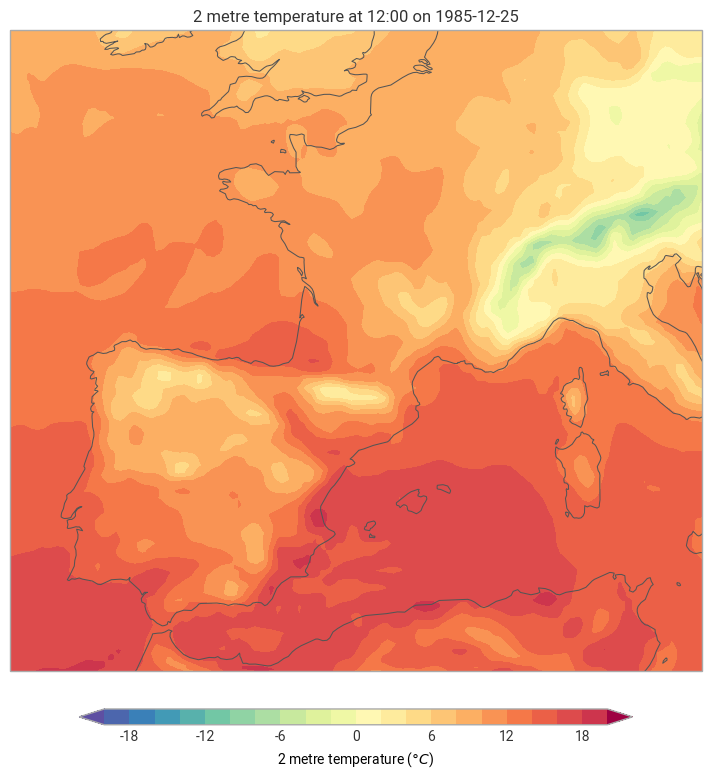

In [3]:
ekp.geo.plot(temperature, domain=["France", "Spain"], style=temperature_style).show()

The same `style` object can be passed to different plot types - earthkit-plots will apply it consistently. For example, the same style works with `grid_cells`:

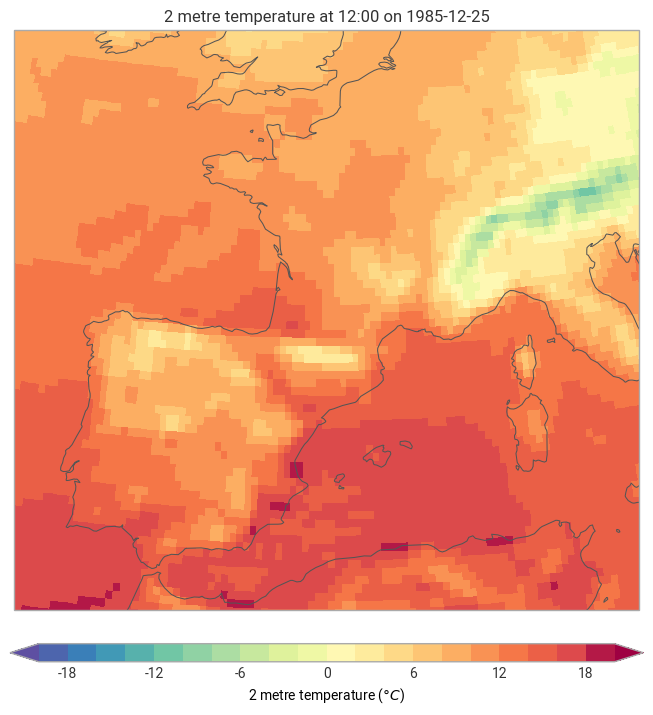

In [4]:
ekp.geo.grid_cells(temperature, domain=["France", "Spain"], style=temperature_style).show()

And with `point_cloud`:

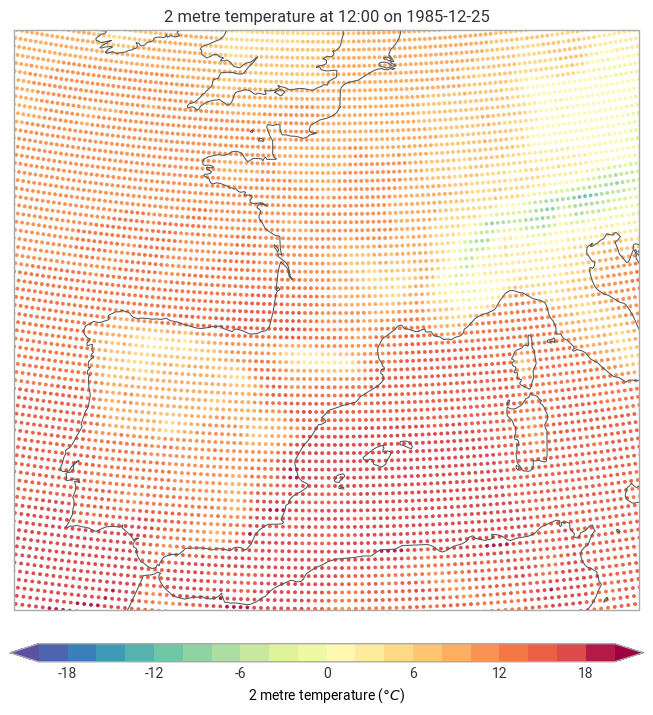

In [5]:
ekp.geo.point_cloud(temperature, domain=["France", "Spain"], style=temperature_style).show()

### Contour styles

earthkit-plots also provides **specialised style classes** for specific plot types. The `Contour` style (`ekp.styles.Contour`) gives fine-grained control over line contour plots.

#### Plotting mean sea-level pressure with a custom contour style

Let's create a contour plot of mean sea-level pressure. We want:

- Contour levels in **hPa** with a **step of 4**
- **Black** contour lines
- A **thicker line every 4 contours** to aid readability
- **Contour labels** drawn on the lines
- **No legend**, since the labels speak for themselves

In [6]:
pressure_style = ekp.styles.Contour(
    # One contour every 4 hPa - all multiples of step by default
    # NOTE: you can also pass a list or range
    levels={"step": 4},
    # Make every contour line black
    colors="black",
    # Convert to hPa at plot time
    units="hPa",
    # Highlight every fourth line with a thicker linewidth
    linewidths=[0.25, 0.25, 0.25, 0.75],
    # Draw labels on the contour lines
    labels=True,
    # No legend for contour plots
    legend_style=None,
)

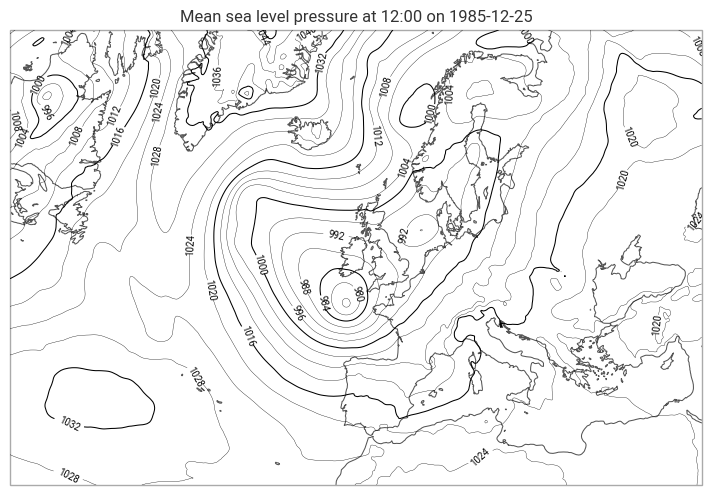

In [7]:
ekp.geo.plot(pressure, domain="North Atlantic", style=pressure_style).show()

### Combining styles in a single chart

Styles become particularly powerful when you overlay multiple layers on the same map. Using the object-oriented API we can add both the temperature `contourf` and the pressure `contour` to a single chart - each with its own independently defined style:

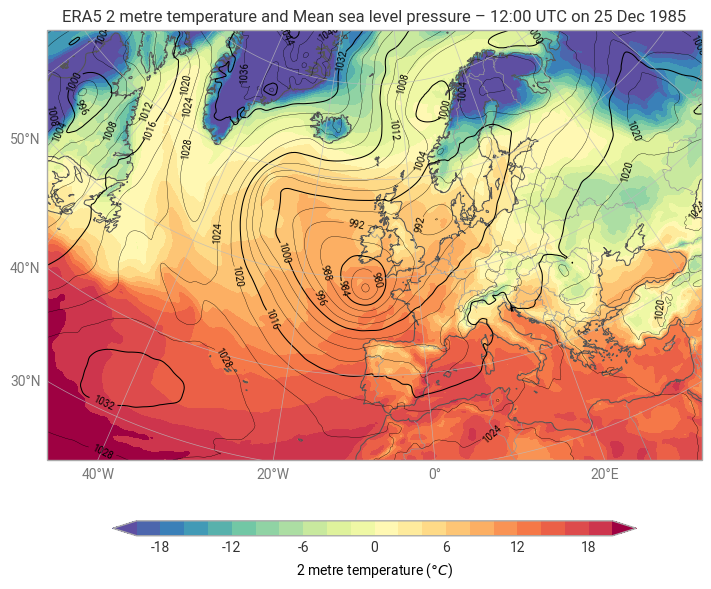

In [8]:
chart = ekp.Map(domain="North Atlantic")
chart.contourf(temperature, style=temperature_style)
chart.contour(pressure, style=pressure_style)
chart.coastlines()
chart.borders()
chart.gridlines()
chart.legend(label="{variable_name} ({units})")
chart.title("ERA5 {variable_name} - {time:%H:%M UTC on %d %b %Y}")
chart.show()

### Customising further

While using [named colormaps from matplotlib](https://matplotlib.org/stable/gallery/color/colormap_reference.html) can give us a lot of options, sometimes we might want to provide our own list of colours. You can either pass a list of colours the length of the list of bins:

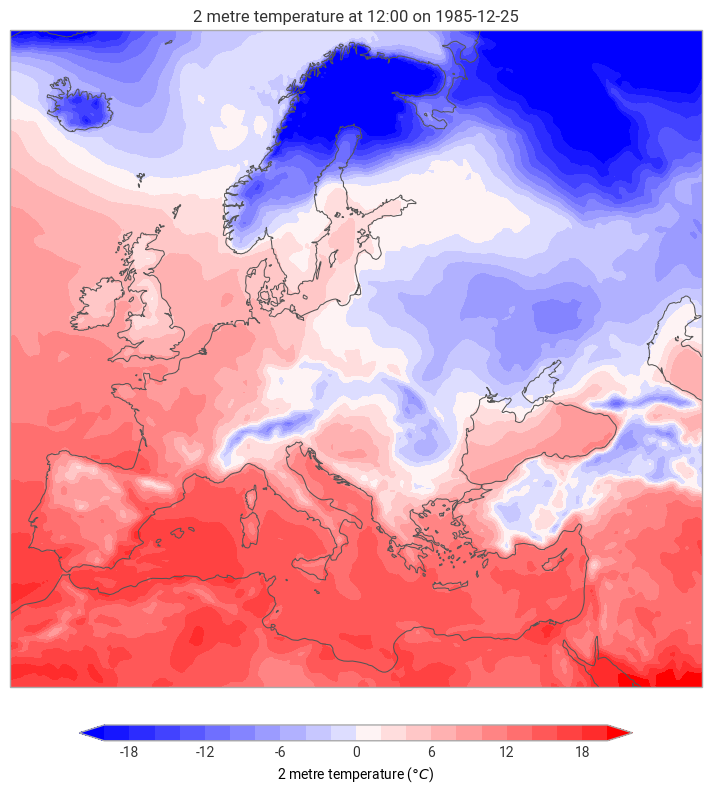

In [9]:
custom_style = ekp.styles.Style(
    levels=range(-20, 21, 2),
    colors=[
        '#0000ff', '#1818ff', '#3030ff', '#4848ff', '#6161ff', '#7979ff',
        '#9191ff', '#aaaaff', '#c2c2ff', '#dadaff', '#f3f3ff', '#fff3f3',
        '#ffdada', '#ffc2c2', '#ffaaaa', '#ff9191', '#ff7979', '#ff6161',
        '#ff4848', '#ff3030', '#ff1818', '#ff0000',
    ],
    units="celsius",
    extend="both",
)
ekp.geo.plot(temperature, domain="Europe", style=custom_style)

Or you can pass fewer colours, in which case earthkit-plots will interpolate between them to get the right number of levels:

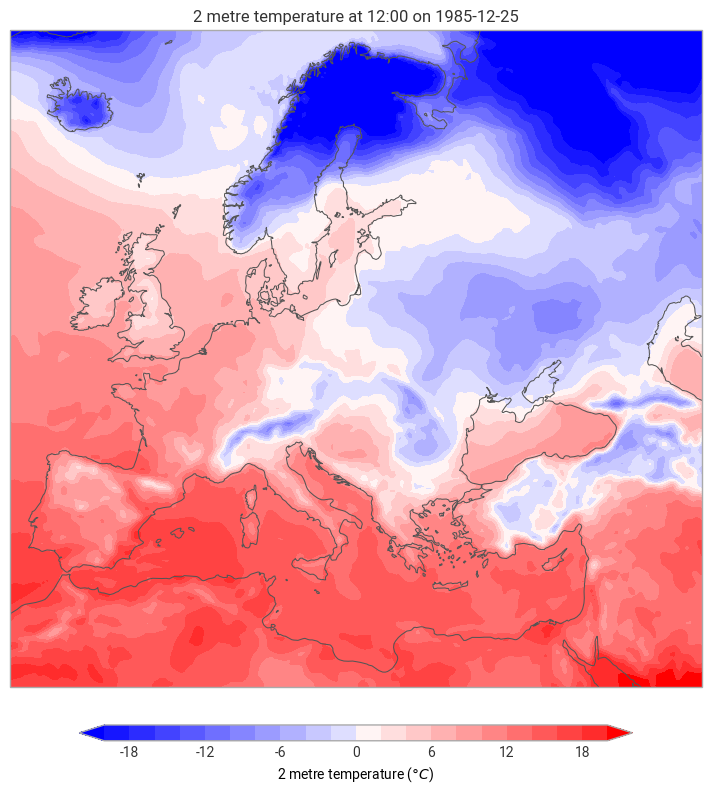

In [10]:
custom_style = ekp.styles.Style(
    levels=range(-20, 21, 2),
    colors=["blue", "white", "red"],
    units="celsius",
    extend="both",
)
ekp.geo.plot(temperature, domain="Europe", style=custom_style)

### Exercises

1. Define a new `Style` for temperature over the USA using a colormap of your choice (see [Colormaps in Matplotlib](https://matplotlib.org/stable/gallery/color/colormap_reference.html), or use your own colour choices), with levels from -30 to 90 **fahrenheit** in steps of 5. Plot the result over the USA. (Hint: you can change the units in the style definition).

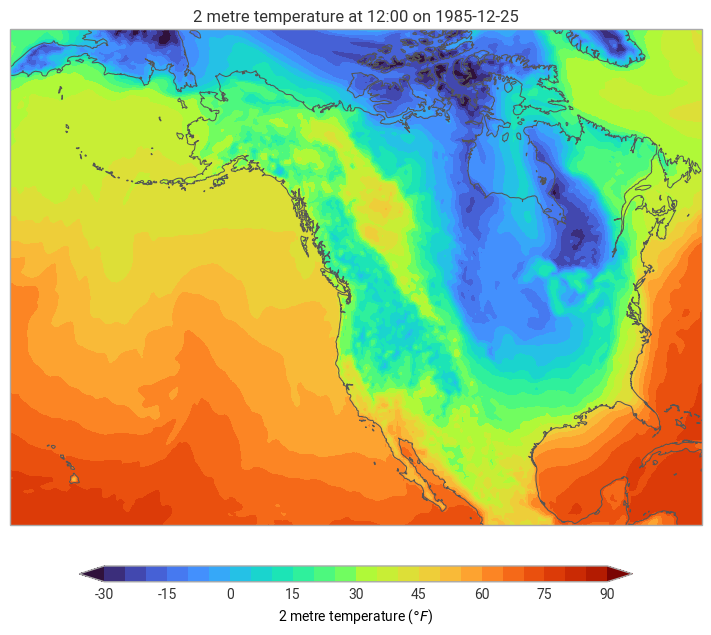

In [11]:
usa_style = ekp.styles.Style(
    levels=range(-30, 91, 5),
    colors="turbo",
    units="fahrenheit",
    extend="both",
)
ekp.geo.plot(temperature, domain="USA", style=usa_style)

2. Can you define a `Contour` style for pressure with red contour lines, a step of 8 hPa and thicker lines every 2 contours? Overlay it on the temperature plot over the USA from exercise 1.

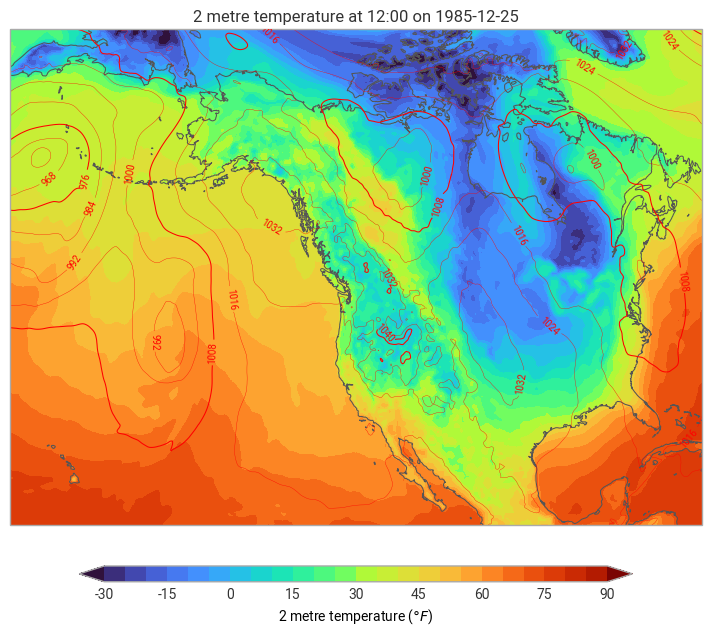

In [12]:
usa_pressure_style = ekp.styles.Contour(
    levels={"step": 8},
    colors="red",
    units="hPa",
    linewidths=[0.25, 0.25, 0.25, 0.75],
    labels=True,
    legend_style=None,
)

ekp.geo.plot(temperature, domain="USA", style=usa_style).plot(pressure, style=usa_pressure_style)